# Time Series Analysis Project

## Objective
Perform exploratory data analysis, statistical tests, and predictive modeling (Linear & Non-Linear) on the DSMTS dataset.

### Steps
1. **Exploratory Data Analysis (EDA)**: Visualizations, Decomposition, Stationarity Tests.
2. **Linear Modeling**: ARIMA Model.
3. **Non-Linear Modeling**: Random Forest Regressor.
4. **Comparison**: Evaluate models based on RMSE and MAE.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuration
DATA_PATH = '../data.csv'  # Adjust path if needed
OUTPUT_DIR = 'plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set plot style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 6)

## 1. Data Loading and Preprocessing

In [2]:
def load_data(path):
    print("Loading data...")
    # Load data
    df = pd.read_csv(path, parse_dates=['timestamp'], index_col='timestamp')
    print(f"Data loaded. Shape: {df.shape}")
    
    # Resample to 1H for analysis to handle the large size (5M points)
    print("Resampling to 1H...")
    df_resampled = df.resample('1h').mean()
    return df_resampled

try:
    df = load_data(DATA_PATH)
    print("Columns:", df.columns)
except FileNotFoundError:
    print(f"File not found at {DATA_PATH}. Please check the path.")
    # Fallback for demonstration if file missing in this context
    # df = pd.DataFrame()

Loading data...
Data loaded. Shape: (5000000, 17)
Resampling to 1H...
Columns: Index(['aimp', 'amud', 'arnd', 'asin1', 'asin2', 'adbr', 'adfl', 'bed1',
       'bed2', 'bfo1', 'bfo2', 'bso1', 'bso2', 'bso3', 'ced1', 'cfo1', 'cso1'],
      dtype='object')


## 2. Exploratory Data Analysis (EDA)

--- Analyzing bso1 ---


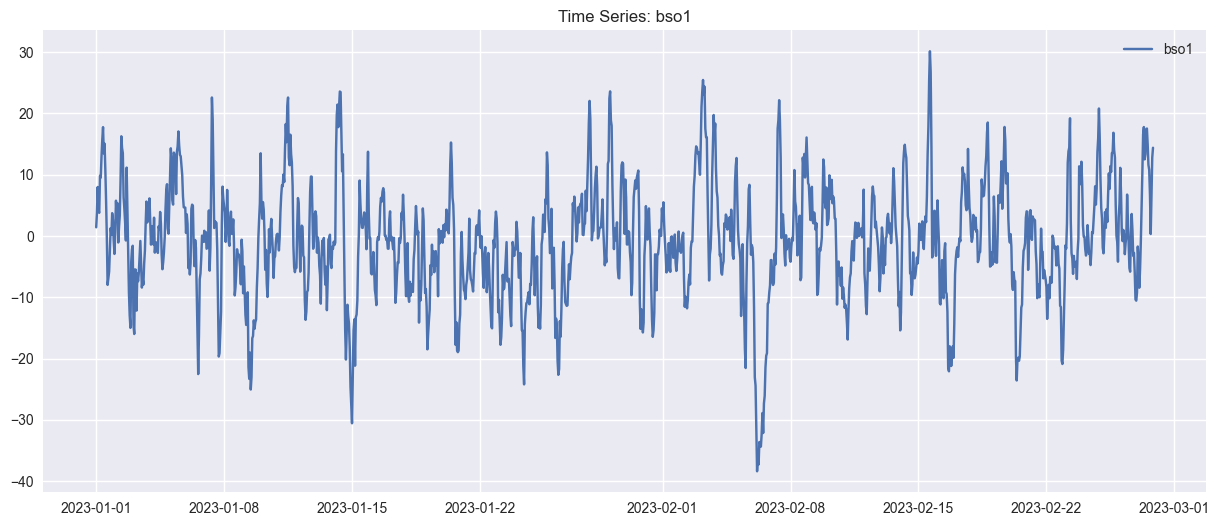

Performing Decomposition...


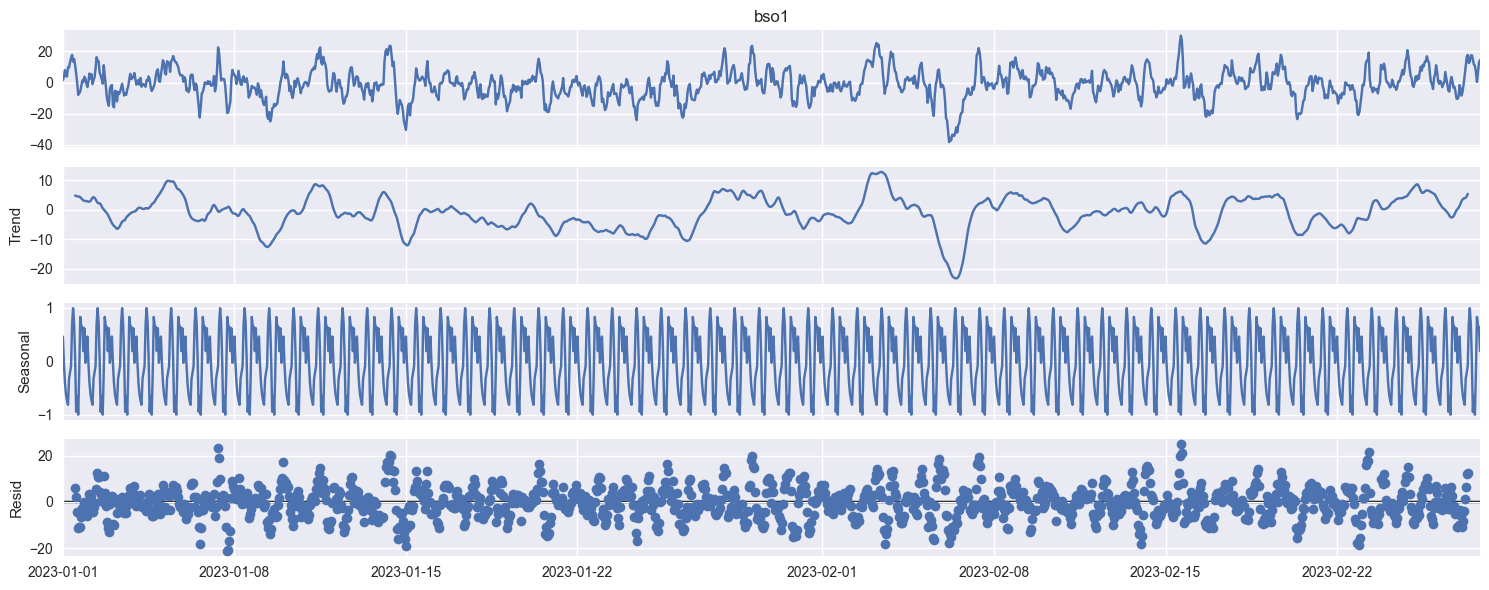

Result of Dickey-Fuller Test:
Test Statistic                -1.077738e+01
p-value                        2.301281e-19
#Lags Used                     1.000000e+00
Number of Observations Used    1.387000e+03
Critical Value (1%)           -3.435073e+00
Critical Value (5%)           -2.863626e+00
Critical Value (10%)          -2.567881e+00
dtype: float64

Conclusion: Data is Stationary (reject H0)


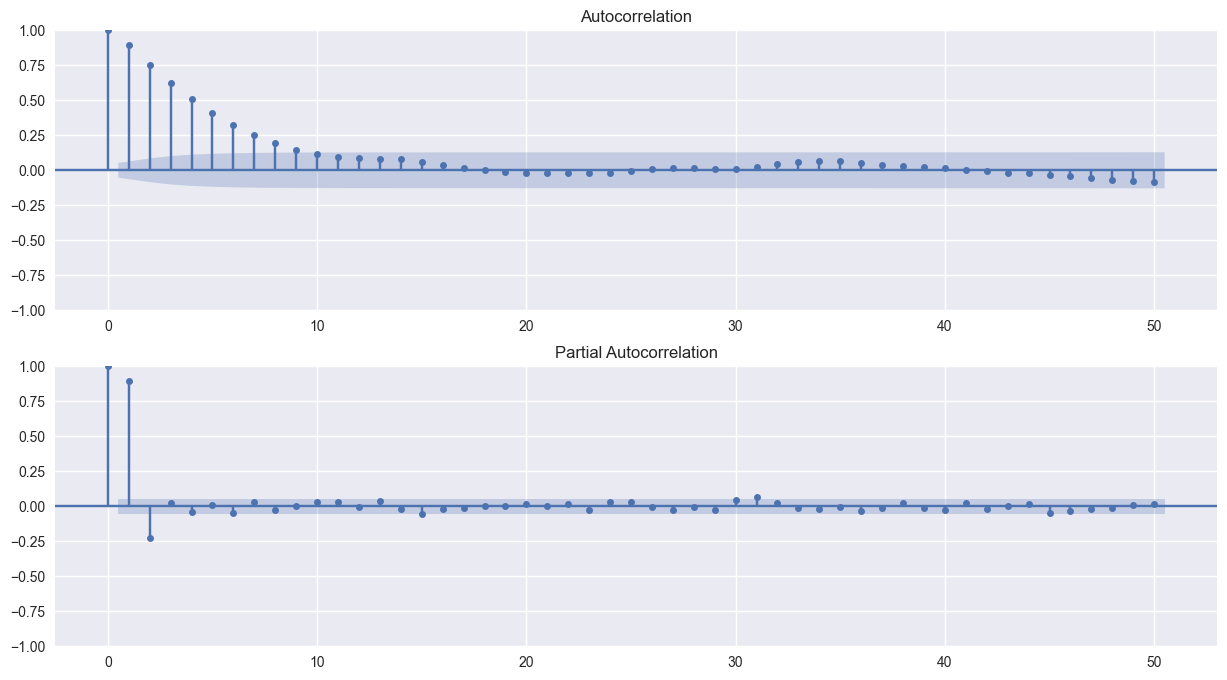

In [3]:
def perform_eda(df, column='bso1'):
    print(f"--- Analyzing {column} ---")
    ts = df[column].dropna()
    
    # 1. Time Series Plot
    plt.figure(figsize=(15, 6))
    plt.plot(ts.index, ts, label=column)
    plt.title(f'Time Series: {column}')
    plt.legend()
    plt.show()
    
    # 2. Decomposition
    print("Performing Decomposition...")
    result = seasonal_decompose(ts, model='additive', period=24)
    result.plot()
    plt.show()
    
    # 3. Stationarity (ADF Test)
    print("Result of Dickey-Fuller Test:")
    dftest = adfuller(ts, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print("\nConclusion: Data is Stationary (reject H0)")
    else:
        print("\nConclusion: Data is Non-Stationary (fail to reject H0)")
        
    # 4. ACF and PACF
    fig, ax = plt.subplots(2, 1, figsize=(15, 8))
    plot_acf(ts, ax=ax[0], lags=50)
    plot_pacf(ts, ax=ax[1], lags=50)
    plt.show()

# Analyze 'bso1'
if not df.empty:
    perform_eda(df, 'bso1')

## 3. Linear Modeling (ARIMA)
We will model the `bso1` variable using an ARIMA model.

Train size: 1111, Test size: 278
Fitting ARIMA(2, 0, 2)...
                               SARIMAX Results                                
Dep. Variable:                   bso1   No. Observations:                 1111
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -3143.353
Date:                Sat, 17 Jan 2026   AIC                           6298.706
Time:                        17:33:31   BIC                           6328.784
Sample:                    01-01-2023   HQIC                          6310.079
                         - 02-16-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1624      0.899     -1.293      0.196      -2.925       0.600
ar.L1          1.5191      0.376      4.041      0.000       0.782      

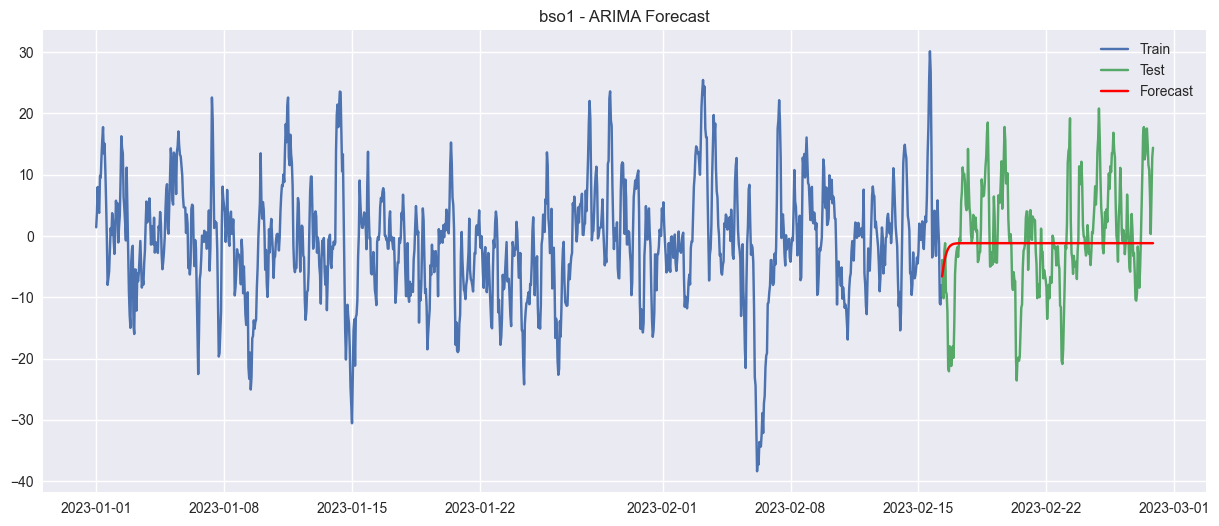

In [4]:
def run_arima(df, column='bso1', order=(2, 0, 2)):
    data = df[column].dropna()
    
    # Split Train/Test
    train_size = int(len(data) * 0.8)
    train, test = data.iloc[:train_size], data.iloc[train_size:]
    print(f"Train size: {len(train)}, Test size: {len(test)}")
    
    # Fit Model
    print(f"Fitting ARIMA{order}...")
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    print(model_fit.summary())
    
    # Forecast
    print("Forecasting...")
    forecast = model_fit.forecast(steps=len(test))
    
    # Evaluation
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)
    print(f'\nARIMA RMSE: {rmse:.4f}')
    print(f'ARIMA MAE: {mae:.4f}')
    
    # Plot
    plt.figure(figsize=(15, 6))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(test.index, forecast, label='Forecast', color='red')
    plt.title(f'{column} - ARIMA Forecast')
    plt.legend()
    plt.show()
    
    return rmse, mae

if not df.empty:
    arima_rmse, arima_mae = run_arima(df, 'bso1', order=(2,0,2))

## 4. Non-Linear Modeling (Random Forest)
We will use a Random Forest Regressor with lag features to capture potential non-linearities.

Training Random Forest...
Forecasting (Recursive)...


/Users/gopal/TSA/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/gopal/TSA/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/gopal/TSA/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/gopal/TSA/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/Users/gopal/TSA/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fit


Random Forest RMSE: 9.1022
Random Forest MAE: 7.1966


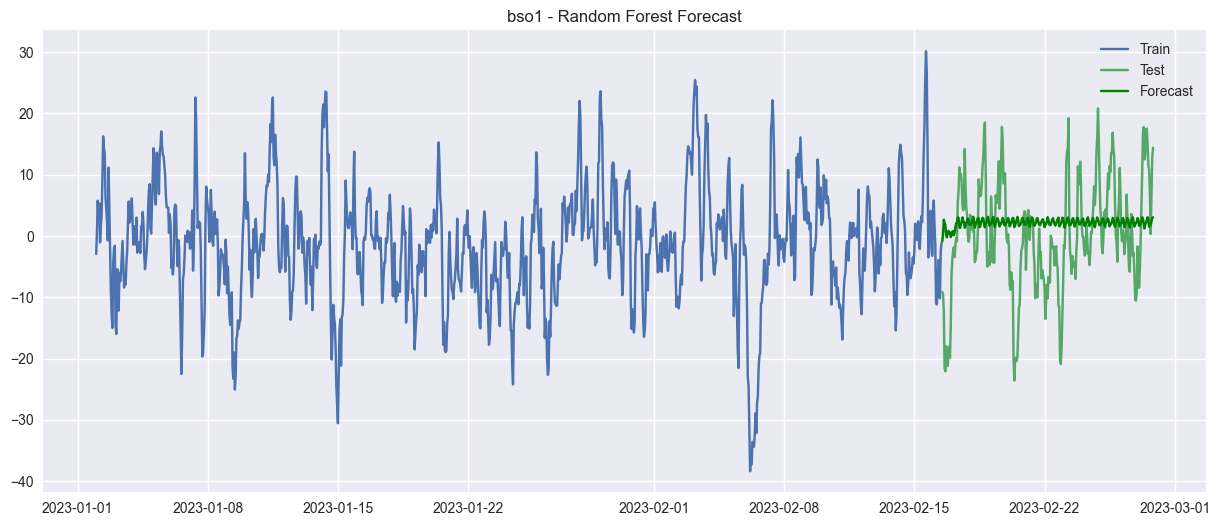

In [5]:
def create_lag_features(df, column, lags=24):
    df_lagged = pd.DataFrame(df[column])
    columns = [df_lagged[column]]
    for i in range(1, lags + 1):
        columns.append(df_lagged[column].shift(i).rename(f'lag_{i}'))
    
    df_lagged = pd.concat(columns, axis=1)
    df_lagged = df_lagged.dropna()
    return df_lagged

def run_random_forest(df, column='bso1', lags=24):
    # Create Features
    df_lagged = create_lag_features(df, column, lags=lags)
    X = df_lagged.drop(columns=[column])
    y = df_lagged[column]
    
    # Split
    train_size = int(len(X) * 0.8)
    train_X, test_X = X.iloc[:train_size], X.iloc[train_size:]
    train_y, test_y = y.iloc[:train_size], y.iloc[train_size:]
    
    # Train
    print("Training Random Forest...")
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(train_X, train_y)
    
    # Recursive Forecast
    print("Forecasting (Recursive)...")
    history = list(train_y.values[-lags:])
    forecasts = []
    
    for i in range(len(test_y)):
        feat = [history[-k] for k in range(1, lags + 1)]
        feat = np.array(feat).reshape(1, -1)
        pred = model.predict(feat)[0]
        forecasts.append(pred)
        history.append(pred)
        
    forecast = np.array(forecasts)
    
    # Evaluation
    rmse = np.sqrt(mean_squared_error(test_y, forecast))
    mae = mean_absolute_error(test_y, forecast)
    print(f'\nRandom Forest RMSE: {rmse:.4f}')
    print(f'Random Forest MAE: {mae:.4f}')
    
    # Plot
    plt.figure(figsize=(15, 6))
    plt.plot(train_y.index, train_y, label='Train')
    plt.plot(test_y.index, test_y, label='Test')
    plt.plot(test_y.index, forecast, label='Forecast', color='green')
    plt.title(f'{column} - Random Forest Forecast')
    plt.legend()
    plt.show()
    
    return rmse, mae

if not df.empty:
    rf_rmse, rf_mae = run_random_forest(df, 'bso1', lags=24)

## Conclusion
Comparing the performance of the Linear (ARIMA) and Non-Linear (Random Forest) models.

In [6]:
if not df.empty:
    results = pd.DataFrame({
        'Model': ['ARIMA', 'Random Forest'],
        'RMSE': [arima_rmse, rf_rmse],
        'MAE': [arima_mae, rf_mae]
    })
    print(results)

           Model      RMSE       MAE
0          ARIMA  9.032298  6.941047
1  Random Forest  9.102150  7.196636
